In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from torch.utils.data import TensorDataset, DataLoader, random_split
from models import CondSM
from tqdm import tqdm
import math
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LogNorm
from utils import pred_vs_true  # only if you actually use it elsewhere

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 12,    # affects horizontal colorbar ticks
    "ytick.labelsize": 12,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 12,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})


import os, random

def set_seed(seed: int, deterministic: bool = False):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        # More reproducible, sometimes slower
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.use_deterministic_algorithms(True)
    else:
        # Faster, may vary slightly run-to-run
        torch.backends.cudnn.benchmark = True

def filled_step_hist(ax, data, bins=20, density=True,
                     facecolor='darkorange', edgecolor='w',
                     alpha=1.0, lw=0.8):
    # 1) Filled step area (no edge)
    ax.hist(
        data, bins=bins, density=density,
        histtype='stepfilled',
        facecolor=facecolor, edgecolor='none',
        alpha=alpha
    )
    # 2) Outline only (no fill)
    ax.hist(
        data, bins=bins, density=density,
        histtype='step',
        facecolor='none', edgecolor=edgecolor,
        linewidth=lw
    )

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
data = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_vMB_ring_1e7/.pth')

In [2]:
dataset_num = 0
dist_type = 'uni_1e7'
data_folder = 'uni_1e7'
data_dir = Path(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/') / data_folder
num_batches = 400
batch_size = 1024
train_size = 0.8
val_size = 0.1
test_size = 0.1
output_idx = 0

In [3]:
voltages = []
currents = []

for i in range(num_batches):

    fp = data_dir / f'batch_{i}.npz'
    try:
        batch = np.load(fp)
    except FileNotFoundError:
        continue        

    voltages.append(batch['inputs'])

    if batch['currents'].ndim != 1:
        currents.append(batch['currents'][:, output_idx])
    else:
        currents.append(batch['currents'])
        
vs = np.concatenate(voltages, axis=0)[..., [i for i in range(voltages[0].shape[1]) if i != output_idx]]
ys = np.concatenate(currents, axis=0)

V = torch.from_numpy(vs).float()

y = torch.from_numpy(ys).unsqueeze(-1).float()
print(V.shape)
print(y.shape)

dataset = TensorDataset(V, y)

generator_1 = torch.Generator().manual_seed(32)
train_ds, val_ds, test_ds = random_split(dataset, lengths=[train_size, val_size, test_size], generator=generator_1)

train_idx = train_ds.indices
y_train = y[train_idx]

mean = y_train.mean(dim=0)
std = y_train.std(dim=0)
print(f'Mean: {mean.item()} nA')
print(f'std: {std.item()} nA')

g = torch.Generator()
g.manual_seed(32)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, generator=g, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, generator=g, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, generator=g, pin_memory=True)

print(f"train_set: {len(train_loader.dataset)}")
print(f"val_set: {len(val_loader.dataset)}")
print(f"test_set: {len(test_loader.dataset)}")
print(torch.isnan(V[val_ds.indices]).any() or torch.isnan(y[train_ds.indices]).any())

y_true_l = []

with torch.no_grad():
    for _, y in test_loader:
        y = y.to(device, non_blocking=True, dtype=torch.float32)
        y_true_l.append(y.cpu().numpy())

y_true = np.concatenate(y_true_l, axis=0).ravel()

torch.Size([200000, 7])
torch.Size([200000, 1])
Mean: -0.017648467794060707 nA
std: 0.17297396063804626 nA
train_set: 160000
val_set: 20000
test_set: 20000
tensor(False)


Text(0.5, 0, '$I \\, [nA]$')

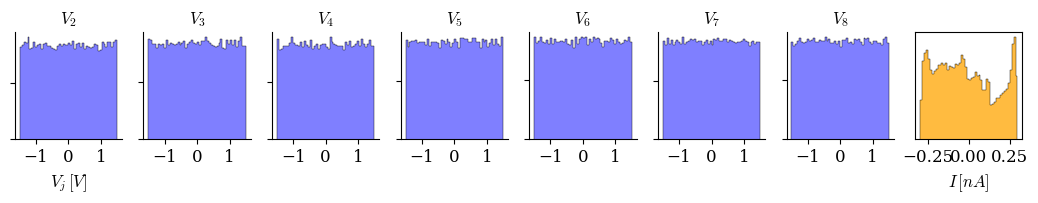

In [16]:
"""VOLTAGE HISTS"""

voltage_samples = []
current_samples = []
for v, y in train_loader:
    voltage_samples.append(v)
    current_samples.append(y)
n_e = 7

voltage_samples = np.concatenate(voltage_samples, axis=0)[:50_000, ...]
current_samples = np.concatenate(current_samples, axis=0)[:50_000, ...]

fig, axs = plt.subplots(ncols=n_e+1, figsize=(13,13))

for j in range(n_e):
    filled_step_hist(axs[j], voltage_samples[:, j], bins=50, density=True, facecolor='blue', edgecolor='k', alpha=.5, lw=0.3)
    #axs[j].minorticks_on()
    if j == 0:
        axs[j].set_xlabel(r'$V_j \, [V]$')    
    axs[j].tick_params(labelleft=False)
    #axs[j].tick_params(which='both', direction='in')
    axs[j].set_box_aspect(1)
    
    axs[j].set_title(label=rf'$V_{j+2}$')
    #axs[j].grid(True, axis="y", alpha=1)
    axs[j].spines["top"].set_visible(False)
    axs[j].spines["right"].set_visible(False)

filled_step_hist(axs[n_e], current_samples, bins=50, density=True, facecolor='orange', edgecolor='k', alpha=.75, lw=0.3)
axs[n_e].set_box_aspect(1)
axs[n_e].tick_params(labelleft=False, labelright=False, left=False, right=False)
axs[n_e].set_xlabel(r'$I \, [nA]$')

#plt.savefig('uni_data_hists.pdf', bbox_inches='tight')

17731
17731
mse_mean=0.00015547391376458108 +- mse_err=2.594722984096362e-05
rmse_mean=0.012425122782588005 +- rmse_err=0.0010441438847392378
r_sq_mean=0.9948877096176147 +- r_sq_err=0.0008532106761327284
lo, hi: -0.31495947 0.30513942


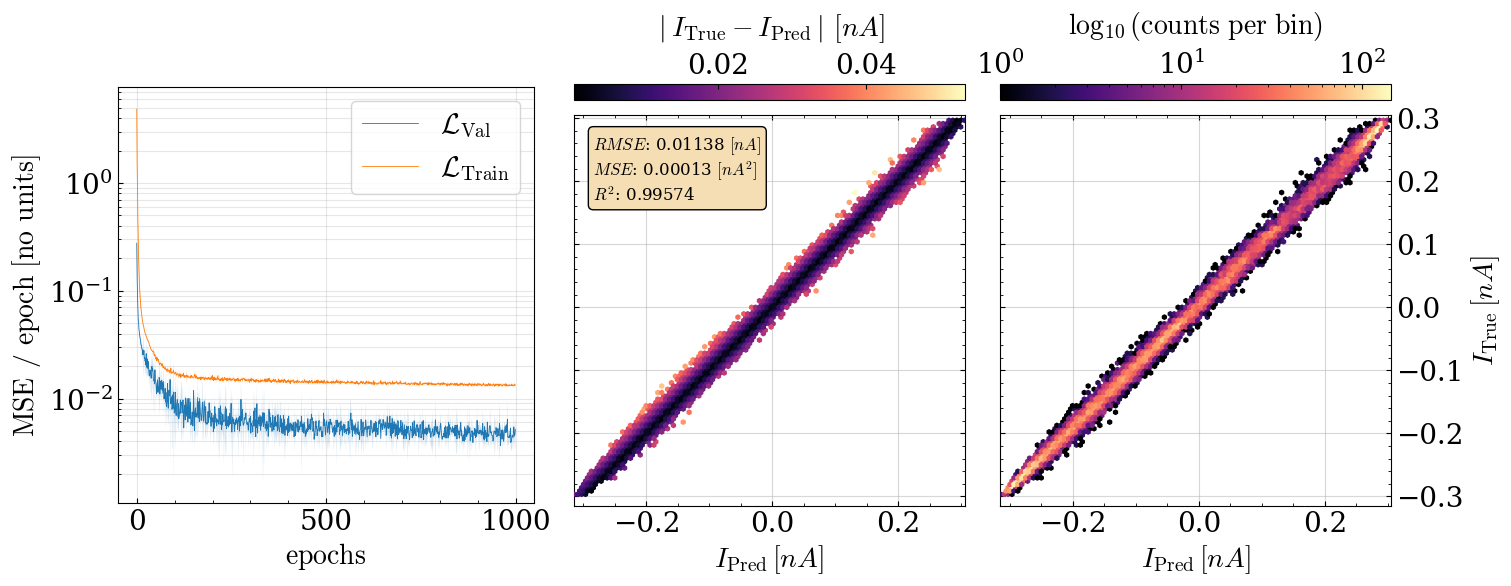

In [33]:
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 20,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 20,    # affects horizontal colorbar ticks
    "ytick.labelsize": 20,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "legend.fontsize": 20,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})


n = 2
num_epochs = 1000
all_val_losses = []
all_train_losses = []
predictions = []
mses = []
rmses = []
r_sqs = []
for i in range(n):
    
    state_dict = torch.load(f"{data_dir}/sm_{dist_type}_baseline_{i}_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth", weights_only=False, map_location='cpu')
    model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
    model.load_state_dict(state_dict['model_state_dict'])
    model.eval()
    model = model.to(device)

    total = sum(p.numel() for p in model.parameters())
    print(total)
    
    val_losses = state_dict['val_losses']
    train_losses = state_dict['train_losses']
    all_val_losses.append(val_losses)
    all_train_losses.append(train_losses)

    pred_params = []
    with torch.no_grad():
        for v, y in test_loader:
            v = v.to(device, non_blocking=True, dtype=torch.float32)
            y = y.to(device, non_blocking=True, dtype=torch.float32)
    
            preds = model(v).detach().cpu().numpy()
            pred_params.append(preds)
    y_pred_l = [params for params in pred_params]
    predictions.append(np.concatenate(y_pred_l, axis=0).ravel())

    mse = np.mean((y_true - predictions[i]) ** 2)
    mses.append(mse)
    rmses.append(np.sqrt(mse))
    r_sqs.append(1 - mse / np.var(y_true))

all_val_losses = np.array(all_val_losses)
all_train_losses = np.array(all_train_losses)

mean_val = all_val_losses.mean(axis=0)
std_val = all_val_losses.std(axis=0, ddof=1)
val_err = std_val / np.sqrt(5)

mean_train = all_train_losses.mean(axis=0)
std_train = all_train_losses.std(axis=0, ddof=1)
train_err = std_val / np.sqrt(5)

"""METRICS"""

mse_mean = np.array(mses).mean()
rmse_mean = np.array(rmses).mean()
r_sq_mean = np.array(r_sqs).mean()

mse_err = np.array(mses).std(ddof=1) / np.sqrt(n)
rmse_err = np.array(rmses).std(ddof=1) / np.sqrt(n)
r_sq_err = np.array(r_sqs).std(ddof=1) / np.sqrt(n)

print(f"mse_mean={mse_mean} +- mse_err={mse_err}")
print(f"rmse_mean={rmse_mean} +- rmse_err={rmse_err}")
print(f"r_sq_mean={r_sq_mean} +- r_sq_err={r_sq_err}")

epochs = np.arange(0, num_epochs)

n_run = 0

lo = min(predictions[n_run].min(), y_true.min())
hi = max(predictions[n_run].max(), y_true.max())  # use max here, not min
print("lo, hi:", lo, hi)
plot_range = [[lo, hi], [lo, hi]]

fig, ax = plt.subplots(ncols=3, figsize=(15, 5), constrained_layout=True)  # 3 columns

plt.minorticks_on()
"""for a in ax:
    a.set_box_aspect(1)"""

# keep the losses panel square if you want
ax[0].set_box_aspect(1)

# make parity panels truly “square in data” (so the plotted region fills the axes)
for a in (ax[1], ax[2]):
    a.set_aspect("equal", adjustable="datalim")
    a.set_xlim(lo, hi)
    a.set_ylim(lo, hi)
    
# ----------------
# LOSSES (left)
# ----------------
ax[0].set_xlabel(r'$\text{epochs}$')
ax[0].set_ylabel(r'$\text{MSE / epoch} \, \, [\text{no units}]$')

ax[0].minorticks_on()
ax[0].tick_params(which='both', direction='in')
ax[0].grid(axis='y', which='both', alpha=0.3, zorder=-1)
ax[0].grid(axis='x', which='major', alpha=0.3, zorder=-1)

val_err = std_val / np.sqrt(n)
train_err = std_train / np.sqrt(n)

ax[0].fill_between(epochs, mean_val - 1.96*val_err, mean_val + 1.96*val_err, alpha=0.2)
ax[0].plot(epochs, mean_val, lw=0.6, label=r'$\mathcal{L}_{\mathrm{Val}}$')

ax[0].fill_between(epochs, mean_train - 1.96*train_err, mean_train + 1.96*train_err, alpha=0.25)
ax[0].plot(epochs, mean_train, lw=0.6, label=r'$\mathcal{L}_{\mathrm{Train}}$')

ax[0].set_yscale('log')
ax[0].legend()

# Shared parity styling helper
def style_parity_axis(a, lo, hi, xlabel, ylabel, show_ylabel=True, ylabel_right=False):
    pad = 0.0
    a.set_xlim(lo - pad, hi + pad)
    a.set_ylim(lo - pad, hi + pad)

    for spine in a.spines.values():
        spine.set_linewidth(1.)

    a.tick_params(direction='in', which='both', width=1, top=True, right=True)
    a.grid(alpha=.3)

    a.set_xlabel(xlabel)

    if show_ylabel:
        a.set_ylabel(ylabel)
        if ylabel_right:
            a.yaxis.set_label_position("right")
            a.yaxis.tick_right()
    else:
        a.set_ylabel("")
        a.tick_params(labelleft=False)  # hide left tick labels (optional)

def top_cbar_ax(parent_ax, height="4%", y=1.02):
    """
    Create an inset axes above `parent_ax` spanning its full width.
    y=1.02 means '2% of the axes height above the top'.
    """
    return inset_axes(
        parent_ax,
        width="100%",
        height=height,
        loc="lower left",
        bbox_to_anchor=(0.0, y, 1.0, 1.0),   # (x0, y0, w, h) in axes coords
        bbox_transform=parent_ax.transAxes,
        borderpad=0.0
    )

# ----------------
# PARITY (middle): color = mean |error|
# ----------------

residuals = predictions[n_run] - y_true
abs_errors = np.abs(residuals)

im_err = ax[1].hexbin(
    predictions[n_run],
    y_true,
    C=abs_errors,
    reduce_C_function=np.mean,
    gridsize=100,
    cmap="magma",
    zorder=5
)

divider1 = make_axes_locatable(ax[1])
cax1 = divider1.append_axes("top", size="4%", pad=0.15)
cbar1 = fig.colorbar(im_err, cax=cax1, orientation="horizontal")
cbar1.set_label(r'$\mid I_{\mathrm{True}} - I_{\mathrm{Pred}} \mid \, [nA]$', labelpad=12)
cax1.xaxis.set_ticks_position("top")
cax1.xaxis.set_label_position("top")
cax1.tick_params(axis="x", which="both", direction="in")
# optional: keep the bar tight and clean
cax1.tick_params(axis="y", left=False, labelleft=False)

# ----------------
# PARITY (right): color = density (counts), LOG colorbar
# ----------------
im_den = ax[2].hexbin(
    predictions[n_run],
    y_true,
    gridsize=100,
    mincnt=1,
    cmap="magma",
    norm=LogNorm(),
    zorder=5
)

# --- TOP colorbar with label on top ---
divider2 = make_axes_locatable(ax[2])
cax2 = divider2.append_axes("top", size="4%", pad=0.15)
cbar2 = fig.colorbar(im_den, cax=cax2, orientation="horizontal")
cbar2.set_label(r'$\log_{10}(\mathrm{counts\ per\ bin})$', labelpad=12)
cax2.xaxis.set_ticks_position("top")
cax2.xaxis.set_label_position("top")
cax2.tick_params(axis="x", which="both", direction="in")
cax2.tick_params(axis="y", left=False, labelleft=False)

ax[1].minorticks_on()
ax[1].tick_params(top=True, right=True, which='both', direction='in')
ax[1].tick_params(labelleft=False)
ax[1].grid(alpha=0.5, zorder=-2)
ax[1].set_xlabel(r'$I_{\mathrm{Pred}} \, [nA]$')

ax[2].minorticks_on()
ax[2].tick_params(top=True, right=True, which='both', direction='in')
ax[2].tick_params(labelleft=False, labelright=True)
ax[2].grid(alpha=0.5, zorder=-2)
ax[2].set_xlabel(r'$I_{\mathrm{Pred}} \, [nA]$')
ax[2].set_ylabel(r'$I_{\mathrm{True}} \, [nA]$')
ax[2].yaxis.set_label_position("right")

plot_text = (
    rf'$RMSE$: {rmses[n_run]:.5f} $[nA]$' + '\n' +
    rf'$MSE$: {mses[n_run]:.5f} $[nA^2]$' + '\n' +
    f'$R^2$: {r_sqs[n_run]:.5f}'
)

props = dict(boxstyle='round', facecolor='wheat', alpha=1)
ax[1].text(
    x=0.05, y=0.95, s=plot_text, transform=ax[1].transAxes,
    bbox=props, va='top', ha='left', zorder=6, fontsize=12
)

# Optional: give a bit more top room if labels feel cramped
#fig.subplots_adjust(wspace=0.05)
#fig.tight_layout()
plt.savefig('train_val_parities_uniform_acceptors.pdf', bbox_inches='tight')
plt.show()

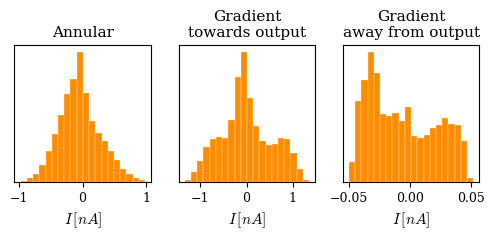

In [52]:
num_batches = 25

datasets = ['data_vMB_ring_1e7', 'grad_towards_1e7', 'grad_away_1e7']

currents_ring = []
currents_towards = []
currents_away = []

for k in range(num_batches):
    data_ring = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_vMB_ring_1e7/batch_{k}.npz')
    data_towards = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/grad_towards_1e7/batch_{k}.npz')
    data_away = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/grad_away_1e7/batch_{k}.npz')    

    currents_ring.append(data_ring['currents'])
    currents_towards.append(data_towards['currents'])
    currents_away.append(data_away['currents'])

fig, axs = plt.subplots(ncols=3, figsize=(6,6))

"""for ax in axs:
    ax.minorticks_on()
    ax.tick_params(left=False, which='both')
    ax.tick_params(which='both', direction='in')"""

axs[0].hist(np.concatenate(currents_ring, axis=0), bins=20, density=True, alpha=1, fc='darkorange', ec='w', lw=0.2)
axs[0].set_box_aspect(1)
axs[0].tick_params(labelleft=False, labelright=False, left=False, right=False)
axs[0].set_xlabel(r'$I \, [nA]$')
axs[0].set_title(r'Annular')

axs[1].hist(np.concatenate(currents_towards, axis=0), bins=20, density=True, alpha=1, fc='darkorange', ec='w', lw=0.2)
axs[1].set_box_aspect(1)
axs[1].tick_params(labelleft=False, labelright=False, left=False, right=False)
axs[1].set_xlabel(r'$I \, [nA]$')
axs[1].set_title('Gradient\ntowards output')

axs[2].hist(np.concatenate(currents_away, axis=0), bins=20, density=True, alpha=1, fc='darkorange', ec='w', lw=0.2)
axs[2].set_box_aspect(1)
axs[2].tick_params(labelleft=False, labelright=False, left=False, right=False)
axs[2].set_xlabel(r'$I \, [nA]$')
axs[2].set_title('Gradient\naway from output')

plt.savefig('current_dists_other_acceptor_configs.pdf', bbox_inches='tight')

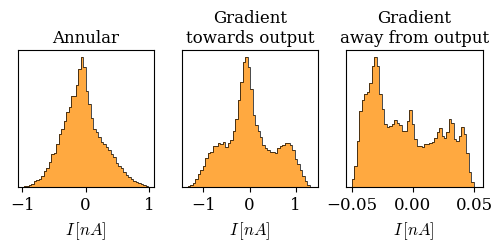

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def filled_step_hist(ax, data, bins=20, density=True,
                     facecolor='darkorange', edgecolor='w',
                     alpha=1.0, lw=0.8):
    # 1) Filled step area (no edge)
    ax.hist(
        data, bins=bins, density=density,
        histtype='stepfilled',
        facecolor=facecolor, edgecolor='none',
        alpha=alpha
    )
    # 2) Outline only (no fill)
    ax.hist(
        data, bins=bins, density=density,
        histtype='step',
        facecolor='none', edgecolor=edgecolor,
        linewidth=lw
    )

num_batches = 25

currents_ring = []
currents_towards = []
currents_away = []

for k in range(num_batches):
    data_ring = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_vMB_ring_1e7/batch_{k}.npz')
    data_towards = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/grad_towards_1e7/batch_{k}.npz')
    data_away = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/grad_away_1e7/batch_{k}.npz')

    currents_ring.append(data_ring['currents'])
    currents_towards.append(data_towards['currents'])
    currents_away.append(data_away['currents'])

ring = np.concatenate(currents_ring, axis=0)
towards = np.concatenate(currents_towards, axis=0)
away = np.concatenate(currents_away, axis=0)

fig, axs = plt.subplots(ncols=3, figsize=(6, 6))

filled_step_hist(axs[0], ring, bins=50, density=True, facecolor='darkorange', edgecolor='k', alpha=.75, lw=0.5)
axs[0].set_box_aspect(1)
axs[0].tick_params(labelleft=False, labelright=False, left=False, right=False)
axs[0].set_xlabel(r'$I \, [nA]$')
axs[0].set_title(r'Annular')

filled_step_hist(axs[1], towards, bins=50, density=True, facecolor='darkorange', edgecolor='k', alpha=.75, lw=0.5)
axs[1].set_box_aspect(1)
axs[1].tick_params(labelleft=False, labelright=False, left=False, right=False)
axs[1].set_xlabel(r'$I \, [nA]$')
axs[1].set_title('Gradient\ntowards output')

filled_step_hist(axs[2], away, bins=50, density=True, facecolor='darkorange', edgecolor='k', alpha=.75, lw=0.5)
axs[2].set_box_aspect(1)
axs[2].tick_params(labelleft=False, labelright=False, left=False, right=False)
axs[2].set_xlabel(r'$I \, [nA]$')
axs[2].set_title('Gradient\naway from output')

plt.savefig('current_dists_other_acceptor_configs.pdf', bbox_inches='tight')


lo, hi: -0.980578 1.0725676


IndexError: list index out of range

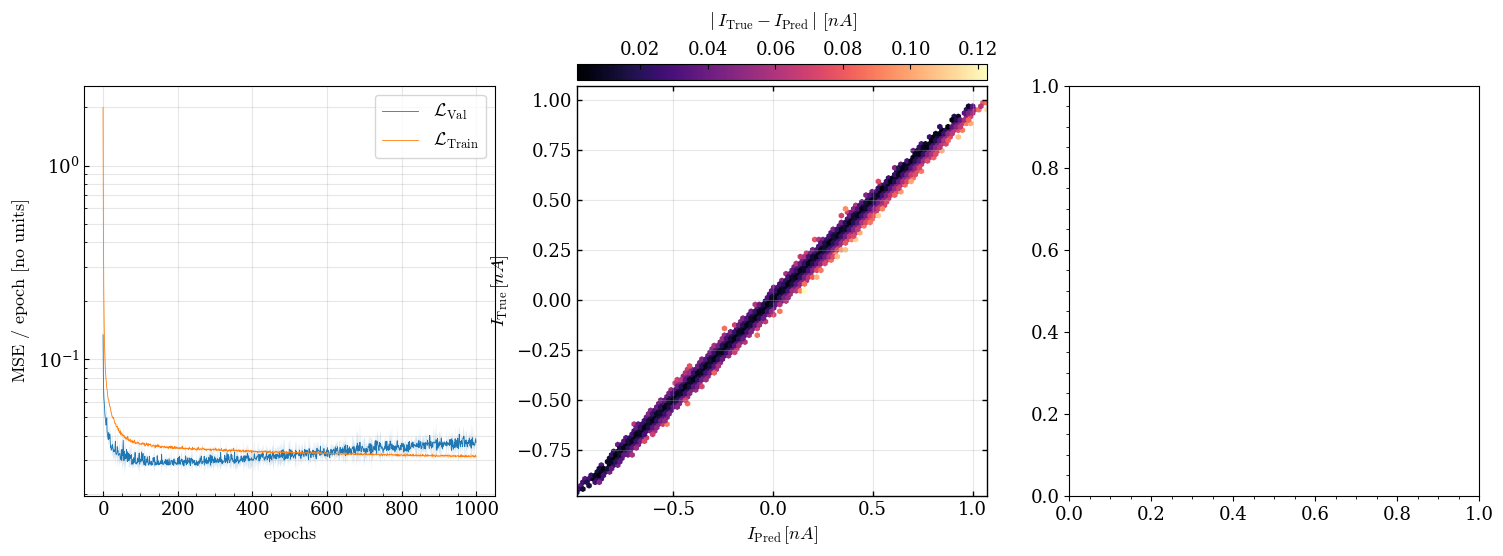

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 13,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 13,    # affects horizontal colorbar ticks
    "ytick.labelsize": 13,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "legend.fontsize": 13,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

state_dict = torch.load(f"{data_dir}/sm_{dist_type}_baseline_3_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth", weights_only=False, map_location='cpu')
model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])
model.eval()
model = model.to(device)

# --- plotting ---
epochs = np.arange(0, num_epochs)
n_run = 0

lo = min(predictions[n_run].min(), y_true.min())
hi = max(predictions[n_run].max(), y_true.max())
print("lo, hi:", lo, hi)

fig, ax = plt.subplots(ncols=3, figsize=(18, 6))  # 3 columns

plt.minorticks_on()
for a in ax:
    a.set_box_aspect(1)

# ----------------
# LOSSES (left)
# ----------------
ax[0].set_xlabel(r'$\text{epochs}$')
ax[0].set_ylabel(r'$\text{MSE / epoch} \, \, [\text{no units}]$')

ax[0].minorticks_on()
ax[0].tick_params(which='both', direction='in')
ax[0].grid(axis='y', which='both', alpha=0.3, zorder=-1)
ax[0].grid(axis='x', which='major', alpha=0.3, zorder=-1)

val_err = std_val / np.sqrt(n)
train_err = std_train / np.sqrt(n)

ax[0].fill_between(epochs, mean_val - 1.96*val_err, mean_val + 1.96*val_err, alpha=0.2)
ax[0].plot(epochs, mean_val, lw=0.6, label=r'$\mathcal{L}_{\mathrm{Val}}$')

ax[0].fill_between(epochs, mean_train - 1.96*train_err, mean_train + 1.96*train_err, alpha=0.25)
ax[0].plot(epochs, mean_train, lw=0.6, label=r'$\mathcal{L}_{\mathrm{Train}}$')

ax[0].set_yscale('log')
ax[0].legend()

# Shared parity styling helper
def style_parity_axis(a, lo, hi, xlabel, ylabel):
    pad = 0.0
    a.set_xlim(lo - pad, hi + pad)
    a.set_ylim(lo - pad, hi + pad)

    """a.plot([lo, hi], [lo, hi],
           linestyle='--', linewidth=2, color='k', alpha=0.7, zorder=6)"""

    for spine in a.spines.values():
        spine.set_linewidth(1.)

    a.tick_params(direction='in', which='both', width=1, top=True, right=True)
    a.grid(alpha=.3)
    a.set_xlabel(xlabel)
    a.set_ylabel(ylabel)

# ----------------
# PARITY (middle): color = mean |error|
# ----------------
style_parity_axis(
    ax[1], lo, hi,
    xlabel=r'$I_{\mathrm{Pred}} \, [nA]$',
    ylabel=r'$I_{\mathrm{True}} \, [nA]$'
)

residuals = predictions[n_run] - y_true
abs_errors = np.abs(residuals)

im_err = ax[1].hexbin(
    predictions[n_run],
    y_true,
    C=abs_errors,
    reduce_C_function=np.mean,
    gridsize=100,
    cmap="magma",
    zorder=-1
)

# --- TOP colorbar with label on top ---
cax1 = inset_axes(
    ax[1],
    width="100%", height="4%",      # wide & short
    loc="upper center",
    borderpad=-1.2                  # tweak if needed
)
cbar1 = fig.colorbar(im_err, cax=cax1, orientation="horizontal")
cbar1.set_label(r'$\mid I_{\mathrm{True}} - I_{\mathrm{Pred}} \mid \, [nA]$')
cbar1.ax.xaxis.set_label_position('top')
cbar1.ax.xaxis.set_ticks_position('top')
cbar1.ax.tick_params(axis='x', direction='in', top=True, bottom=False)
cbar1.ax.xaxis.labelpad = 11

plot_text = (
    rf'$RMSE$: {rmses[n_run]:.5f} $[nA]$' + '\n' +
    rf'$MSE$: {mses[n_run]:.5f} $[nA^2]$' + '\n' +
    f'$R^2$: {r_sqs[n_run]:.5f}'
)
props = dict(boxstyle='round', facecolor='wheat', alpha=1)
ax[1].text(
    x=0.05, y=0.95, s=plot_text, transform=ax[1].transAxes,
    bbox=props, va='top', ha='left', zorder=6, fontsize=9
)

# ----------------
# PARITY (right): color = density (counts), LOG colorbar
# ----------------
style_parity_axis(
    ax[2], lo, hi,
    xlabel=r'$I_{\mathrm{Pred}} \, [nA]$',
    ylabel=r'$I_{\mathrm{True}} \, [nA]$'
)

im_den = ax[2].hexbin(
    predictions[n_run],
    y_true,
    gridsize=100,
    mincnt=1,
    cmap="magma",
    norm=LogNorm(),
    zorder=-1
)

# --- TOP colorbar with label on top ---
cax2 = inset_axes(
    ax[2],
    width="100%", height="4%",
    loc="upper center",
    borderpad=-1.2
)
cbar2 = fig.colorbar(im_den, cax=cax2, orientation="horizontal")
cbar2.set_label(r'$\log_{10}(\mathrm{counts\ per\ bin})$')
cbar2.ax.xaxis.set_label_position('top')
cbar2.ax.xaxis.set_ticks_position('top')
cbar2.ax.tick_params(axis='x', direction='in', top=True, bottom=False)
cbar2.ax.xaxis.labelpad = 11

# Optional: give a bit more top room if labels feel cramped
fig.subplots_adjust(wspace=0.3)
plt.savefig('train_val_parities_uniform_acceptors.pdf', bbox_inches='tight')
plt.show()